# 02 · RL Portfolio Environment

Gymnasium-compatible environment for PPO-based portfolio optimization.
One environment per risk profile (conservative / balanced / aggressive).

This is the v7 environment, unchanged, with ONE ablation flag added:
  USE_FULL_UNIVERSE — when True, the profile mask is overridden to all-ones,
  so the agent trades the full 31-stock universe instead of the ~10-stock
  universe selected by the volatility-clustering classifier. This removes the
  fourth (classifier) model from the pipeline; personalization is intended to
  come from REWARD_CONFIGS instead of universe filtering.

Run protocol:
  1. First run with USE_FULL_UNIVERSE = False to confirm this harness
     reproduces the recorded v7 result (+0.636 mean Sharpe, +0.311 margin,
     4/4 significant). This is the control.
  2. Then run with USE_FULL_UNIVERSE = True for the ablation.

v7 architectural features (unchanged):
  - VecEnv (DummyVecEnv) for richer rollout diversity during training
  - Multi-episode evaluation across all valid start indices per eval window
  - Block bootstrap confidence intervals for Sharpe and annualized return
  - Walk-forward retraining: expanding windows across 2015-2026
  - Market regime signal [T, 3] in observation: egx30_ma_ratio, conia_delta,
    inflation_delta
  - Return-based reward with downside/drawdown/hhi/cash penalties
  - Per-period CVaR; proportional timesteps per fold

## 1. Imports

In [31]:
from pathlib import Path
import json
import subprocess
import sys
import numpy as np
import pandas as pd
import torch
from scipy import stats
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import (
    EvalCallback,
    StopTrainingOnNoModelImprovement,
    BaseCallback,
)
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

## 2. Configuration

In [32]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR      = Path("../../")
DATA_DIR      = BASE_DIR / "data"
TENSORS_DIR   = DATA_DIR / "processed/tensors"
METADATA_DIR  = DATA_DIR / "processed/metadata"

MARKET_DATA_PATH = BASE_DIR / "data/macro/market_data.csv"
RRFR_SCRIPT_PATH = BASE_DIR / "src/ingestion/EGX30_RRFR.py"

In [33]:
# ── Version and profile ───────────────────────────────────────────────────────
VERSION      = "v7_cap80"          # full-universe ablation (separate output folder)
RISK_PROFILE = "balanced"     # only the balanced agent is trained/evaluated

In [34]:
# ── Universe mode (v7b ablation) ──────────────────────────────────────────────
# False = use the volatility-clustering profile mask (original v7, ~10 stocks/day).
#         Run this first as the CONTROL — it should reproduce v7's +0.636 / +0.311.
# True  = ignore the profile mask; the agent trades the full 31-stock universe.
#         Personalization comes from REWARD_CONFIGS, not the universe.
USE_FULL_UNIVERSE = False

In [35]:
# ── Risk-free rate ────────────────────────────────────────────────────────────
# Hardcoded to 0.21 to match v7's recorded run (its RRFR script fell back to
# 0.21) and keep all version comparisons apples-to-apples.
ANNUAL_RISK_FREE_RATE = 0.21

In [36]:
# ── Episode structure ─────────────────────────────────────────────────────────
EPISODE_LENGTH   = 24
REBALANCE_DAYS   = 21
PERIODS_PER_YEAR = 252 / 21

In [37]:
# ── Action space constraints ──────────────────────────────────────────────────
MAX_CASH_WEIGHT  = 0.30
MAX_STOCK_WEIGHT = 0.20
MIN_STOCK_WEIGHT = 0.0

In [38]:
# ── Transaction costs ─────────────────────────────────────────────────────────
BASE_TRANSACTION_COST = 0.0064
MAX_TRANSACTION_COST  = 0.015
TURNOVER_CAP = 0.80

In [39]:
# ── VecEnv parallelism ────────────────────────────────────────────────────────
N_ENVS = 4

In [40]:
# ── Walk-forward configuration ────────────────────────────────────────────────
WALK_FORWARD_FOLDS = [
    {"name": "fold_1", "train_end": "2019-12-31", "val_end": "2020-12-31", "test_end": "2021-12-31"},
    {"name": "fold_2", "train_end": "2020-12-31", "val_end": "2021-12-31", "test_end": "2022-12-31"},
    {"name": "fold_3", "train_end": "2021-12-31", "val_end": "2022-12-31", "test_end": "2023-12-31"},
    {"name": "fold_4", "train_end": "2022-12-31", "val_end": "2023-12-31", "test_end": "2025-12-31"},
]

BASE_TIMESTEPS = 3_500_000

In [41]:
# ── Multi-episode evaluation ──────────────────────────────────────────────────
MAX_EVAL_EPISODES = 50

# ── Block bootstrap ───────────────────────────────────────────────────────────
N_BOOTSTRAP      = 2000
BOOTSTRAP_BLOCK  = 3
CONFIDENCE_LEVEL = 0.95

In [42]:
# ── PPO hyperparameters (unchanged from v7) ───────────────────────────────────
PPO_PARAMS = {
    "policy":          "MlpPolicy",
    "learning_rate":   3e-4,
    "n_steps":         2048,
    "batch_size":      64,
    "n_epochs":        10,
    "gamma":           0.995,
    "gae_lambda":      0.95,
    "clip_range":      0.2,
    "ent_coef":        0.01,
    "vf_coef":         0.5,
    "max_grad_norm":   0.5,
    "verbose":         0,
    "policy_kwargs": {
        "net_arch":      [256, 256, 256],
        "activation_fn": __import__("torch.nn", fromlist=["Tanh"]).Tanh,
    },
}

In [43]:
# ── Reward configs (unchanged from v7) ────────────────────────────────────────
REWARD_CONFIGS = {
    "conservative": {
        "return_weight":    1.0,
        "turnover_penalty": 0.002,
        "downside_penalty": 2.0,
        "drawdown_penalty": 3.0,
        "hhi_penalty":      0.8,
        "cash_penalty":     0.5,
    },
    "balanced": {
        "return_weight":    1.0,
        "turnover_penalty": 0.01,
        "downside_penalty": 0.8,
        "drawdown_penalty": 1.0,
        "hhi_penalty":      0.3,
        "cash_penalty":     2.0,
    },
    "aggressive": {
        "return_weight":    1.0,
        "turnover_penalty": 0.002,
        "downside_penalty": 0.0,
        "drawdown_penalty": 0.0,
        "hhi_penalty":      0.1,
        "cash_penalty":     3.0,
    },
}

In [44]:
PALETTE = {
    "primary":   "#2c7bb6",
    "secondary": "#d7191c",
    "tertiary":  "#fdae61",
    "accent":    "#abd9e9",
    "train":     "#2c7bb6",
    "val":       "#fdae61",
    "test":      "#2ca25f",
    "alert":     "#d7191c",
}

## 3. Risk-Free Rate

In [45]:
PERIOD_RISK_FREE_RATE = (1 + ANNUAL_RISK_FREE_RATE) ** (21 / 252) - 1
print(f"  Annual rate     : {ANNUAL_RISK_FREE_RATE*100:.2f}%  (hardcoded, matches v7)")
print(f"  Per-period rate : {PERIOD_RISK_FREE_RATE*100:.4f}%  (21-day equivalent)")

  Annual rate     : 21.00%  (hardcoded, matches v7)
  Per-period rate : 1.6012%  (21-day equivalent)


## 4. Load Artifacts

In [46]:
feature_tensor = torch.load(
    TENSORS_DIR / "feature_tensor.pt", weights_only=False
).numpy()

returns_tensor = torch.load(
    TENSORS_DIR / "returns_tensor.pt", weights_only=False
).numpy()

mask_tensor = torch.load(
    TENSORS_DIR / "mask_tensor.pt", weights_only=False
).numpy()

# ── Market regime signal [T, 3] ───────────────────────────────────────────────
# col0=egx30_ma_ratio, col1=conia_delta, col2=inflation_delta
market_signal = torch.load(
    TENSORS_DIR / "market_signal.pt", weights_only=False
).numpy()

# ── Profile mask tensor [T, N] ────────────────────────────────────────────────
profile_mask_tensor = torch.load(
    TENSORS_DIR / "profile_mask_tensor.pt", weights_only=False
).numpy()

# ── v7b ablation: optionally override the profile mask to all-ones ─────────────
# When USE_FULL_UNIVERSE is True, _get_combined_mask reduces to the availability
# mask alone, so the agent can trade any stock that has price data on that day.
# The equal-weight baseline uses the same _get_combined_mask, so the comparison
# stays fair (full-universe RL vs full-universe EQW).
if USE_FULL_UNIVERSE:
    profile_mask_tensor = np.ones_like(profile_mask_tensor)
    print(f"USE_FULL_UNIVERSE=True — profile mask overridden to all-ones "
          f"(full 31-stock universe; classifier model removed)")
else:
    print(f"USE_FULL_UNIVERSE=False — using volatility-clustering profile mask "
          f"(original v7 behaviour; CONTROL run)")

USE_FULL_UNIVERSE=False — using volatility-clustering profile mask (original v7 behaviour; CONTROL run)


In [47]:
with open(METADATA_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

with open(METADATA_DIR / "split_indices.json") as f:
    global_split_indices = json.load(f)

with open(METADATA_DIR / "meta.json") as f:
    meta = json.load(f)

with open(METADATA_DIR / "date_index.json") as f:
    date_index = json.load(f)

with open(METADATA_DIR / "market_signal_stats.json") as f:
    market_signal_stats = json.load(f)

In [48]:
print(f"Feature tensor  : {feature_tensor.shape}  (T, N_stocks, N_features)")
print(f"Returns tensor  : {returns_tensor.shape}  (T, N_stocks)")
print(f"Mask tensor     : {mask_tensor.shape}  (T, N_stocks)")
print(f"Market signal   : {market_signal.shape}  (T, 3)  "
      f"egx30=[{market_signal[:,0].min():.3f}, {market_signal[:,0].max():.3f}]  "
      f"conia=[{market_signal[:,1].min():.3f}, {market_signal[:,1].max():.3f}]  "
      f"inflation=[{market_signal[:,2].min():.3f}, {market_signal[:,2].max():.3f}]")
print(f"Profile mask    : {profile_mask_tensor.shape}  "
      f"coverage={profile_mask_tensor.mean()*100:.1f}% "
      f"({'FULL UNIVERSE' if USE_FULL_UNIVERSE else RISK_PROFILE})")
print(f"Date range      : {date_index[0]} to {date_index[-1]}")
print(f"Tickers         : {meta['n_stocks']}")

assert market_signal.shape[0] == feature_tensor.shape[0], \
    "market_signal T dimension must match feature_tensor T dimension"
assert not np.isnan(market_signal).any(), \
    "market_signal contains NaN — check notebook 01 trimming"
assert market_signal.shape[1] == 3, \
    f"Expected 3 market signals, got {market_signal.shape[1]}"
assert profile_mask_tensor.shape == mask_tensor.shape, \
    f"Profile mask shape {profile_mask_tensor.shape} != mask tensor shape {mask_tensor.shape}"

print(f"\nAll tensors loaded and validated.")

Feature tensor  : (2607, 31, 9)  (T, N_stocks, N_features)
Returns tensor  : (2607, 31)  (T, N_stocks)
Mask tensor     : (2607, 31)  (T, N_stocks)
Market signal   : (2607, 3)  (T, 3)  egx30=[-4.194, 3.423]  conia=[-2.413, 6.619]  inflation=[-3.551, 3.231]
Profile mask    : (2607, 31)  coverage=31.0% (balanced)
Date range      : 2015-07-06 to 2026-03-31
Tickers         : 31

All tensors loaded and validated.


In [49]:
date_to_idx = {d: i for i, d in enumerate(date_index)}

## 5. Universe (All Tickers — Profile Filtering via Mask)

In [50]:
all_tickers      = meta["tickers"]
universe_tickers = sorted(all_tickers)
universe_indices = list(range(len(all_tickers)))
REL_VOL_IDX      = feature_names.index("rel_volume")

print(f"Universe : {len(universe_tickers)} stocks (all tickers)")
print(f"Profile filtering applied dynamically at each step via profile_mask_tensor")
print(f"Tickers  : {universe_tickers}")

Universe : 31 stocks (all tickers)
Profile filtering applied dynamically at each step via profile_mask_tensor
Tickers  : ['ABUK', 'ADIB', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'COMI', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EGCH', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'OIH', 'ORAS', 'ORHD', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'TMGH', 'VLMR', 'VLMRA']


## 6. PortfolioEnv Class

In [51]:
class PortfolioEnv(gym.Env):
    """
    Gymnasium-compatible portfolio optimization environment.

    Observation vector layout:
        [0 : N*F]            per-stock features, flattened (N x F numbers)
        [N*F : N*F+N]        current stock weights          (N numbers)
        [N*F+N]              current cash weight             (1 number)
        [N*F+N+1 : N*F+N+4]  market signals                 (3 numbers)
                             col0=egx30_ma_ratio, col1=conia_delta, col2=inflation_delta
        Total: N*F + N + 1 + 3

    Dynamic universe filtering (Design B):
        combined_mask = availability_mask & profile_mask
        Stocks failing either check are zeroed and forced to zero weight.
        N stays fixed at 31. When USE_FULL_UNIVERSE overrides profile_mask to
        all-ones, the combined mask reduces to availability alone.
    """

    def __init__(
        self,
        feature_tensor,
        returns_tensor,
        mask_tensor,
        market_signal,
        profile_mask_tensor,
        universe_indices,
        split_indices,
        risk_profile,
        feature_names,
        mode="train",
        episode_length=24,
        rebalance_days=21,
        silent=False,
    ):
        super().__init__()

        self.feature_tensor      = feature_tensor
        self.returns_tensor      = returns_tensor
        self.mask_tensor         = mask_tensor
        self.market_signal       = market_signal
        self.profile_mask_tensor = profile_mask_tensor
        self.universe_indices    = universe_indices
        self.feature_names       = feature_names
        self.risk_profile        = risk_profile
        self.mode                = mode
        self.episode_length      = episode_length
        self.rebalance_days      = rebalance_days

        self.N = len(universe_indices)
        self.F = feature_tensor.shape[2]
        self.T = feature_tensor.shape[0]

        self.reward_cfg  = REWARD_CONFIGS[risk_profile]
        self.rel_vol_idx = REL_VOL_IDX

        rows_needed = episode_length * rebalance_days
        available   = split_indices[mode]
        self.valid_starts = [
            i for i in available
            if i + rows_needed < self.T
        ]

        obs_dim = self.N * self.F + self.N + 1 + 3
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-10.0, high=10.0, shape=(self.N + 1,), dtype=np.float32
        )

        if not silent:
            print(f"PortfolioEnv [{mode}] : {self.N} stocks | "
                  f"{len(self.valid_starts)} valid starts | "
                  f"obs=({obs_dim},) = {self.N}x{self.F} features "
                  f"+ {self.N} stock weights + 1 cash + 3 market signals")

        self.current_step    = 0
        self.start_idx       = 0
        self.current_weights = np.zeros(self.N + 1, dtype=np.float32)
        self.portfolio_value = 1.0
        self.peak_value      = 1.0
        self.episode_returns = []

    def _get_combined_mask(self, day_idx):
        """
        Combines availability mask with profile mask.
        A stock is tradeable only if it has price data AND is currently in the
        profile universe. When profile_mask is all-ones (USE_FULL_UNIVERSE),
        this reduces to the availability mask alone.
        """
        avail_mask   = self.mask_tensor[day_idx, self.universe_indices]
        profile_mask = self.profile_mask_tensor[day_idx, self.universe_indices]
        return (avail_mask * profile_mask).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if options is not None and "start_idx" in options:
            self.start_idx = options["start_idx"]
        elif self.mode == "train":
            self.start_idx = int(np.random.choice(self.valid_starts))
        else:
            self.start_idx = self.valid_starts[0]

        self.current_step    = 0
        self.portfolio_value = 1.0
        self.peak_value      = 1.0
        self.episode_returns = []
        self.current_weights = np.full(
            self.N + 1, 1.0 / (self.N + 1), dtype=np.float32
        )

        return self._get_observation(), {}

    def _get_observation(self):
        day_idx = self.start_idx + self.current_step * self.rebalance_days

        combined_mask  = self._get_combined_mask(day_idx)
        stock_features = self.feature_tensor[day_idx, self.universe_indices, :]
        stock_features = stock_features * combined_mask[:, np.newaxis]

        regime_signal = self.market_signal[day_idx].astype(np.float32)  # shape [3]

        return np.concatenate([
            stock_features.flatten(),
            self.current_weights[:-1],
            self.current_weights[-1:],
            regime_signal,
        ]).astype(np.float32)

    def _apply_position_limits(self, weights, stock_mask):
        stock_weights = weights[:-1].copy()
        for _ in range(10):
            if not (stock_weights > MAX_STOCK_WEIGHT).any():
                break
            for i in range(len(stock_weights)):
                if stock_weights[i] > MAX_STOCK_WEIGHT:
                    excess           = stock_weights[i] - MAX_STOCK_WEIGHT
                    stock_weights[i] = MAX_STOCK_WEIGHT
                    eligible = np.array([
                        j for j in range(len(stock_weights))
                        if j != i and stock_mask[j] == 1
                        and stock_weights[j] < MAX_STOCK_WEIGHT
                    ])
                    if len(eligible) > 0:
                        s = stock_weights[eligible].sum()
                        if s > 1e-8:
                            stock_weights[eligible] += excess * (
                                stock_weights[eligible] / s
                            )
                        else:
                            stock_weights[eligible] += excess / len(eligible)
                    else:
                        weights[-1] += excess
        weights[:-1] = stock_weights
        return weights

    def _liquidity_adjusted_cost(self, day_idx, stock_turnover):
        rel_vol = self.feature_tensor[
            day_idx, self.universe_indices, self.rel_vol_idx
        ]
        max_mult       = MAX_TRANSACTION_COST / BASE_TRANSACTION_COST
        liquidity_mult = np.clip(1.0 - 0.3 * rel_vol, 1.0, max_mult)
        per_stock_cost = BASE_TRANSACTION_COST * liquidity_mult
        return float(np.dot(np.abs(stock_turnover), per_stock_cost))

    def step(self, action):
        action      = np.array(action, dtype=np.float32)
        exp_action  = np.exp(action - action.max())
        raw_weights = exp_action / exp_action.sum()

        day_idx    = self.start_idx + self.current_step * self.rebalance_days
        stock_mask = self._get_combined_mask(day_idx)
        raw_weights[:-1] *= stock_mask

        weight_sum = raw_weights.sum()
        if weight_sum > 1e-8:
            raw_weights = raw_weights / weight_sum
        else:
            raw_weights     = np.zeros(self.N + 1, dtype=np.float32)
            raw_weights[-1] = 1.0

        if raw_weights[-1] > MAX_CASH_WEIGHT:
            excess          = raw_weights[-1] - MAX_CASH_WEIGHT
            raw_weights[-1] = MAX_CASH_WEIGHT
            stock_sum       = raw_weights[:-1].sum()
            if stock_sum > 1e-8:
                raw_weights[:-1] += excess * (raw_weights[:-1] / stock_sum)
            else:
                valid_idx = np.where(stock_mask == 1)[0]
                if len(valid_idx) > 0:
                    raw_weights[valid_idx] += excess / len(valid_idx)
                else:
                    raw_weights[-1] = 1.0
            s = raw_weights.sum()
            if s > 1e-8:
                raw_weights = raw_weights / s

        raw_weights = self._apply_position_limits(raw_weights, stock_mask)

        s = raw_weights.sum()
        new_weights = raw_weights / s if s > 1e-8 else (
            np.zeros(self.N + 1, dtype=np.float32) + [0.0] * self.N + [1.0]
        )

        # ── Turnover cap ────────────────────────────────────────────────────
        # Scale all trades back proportionally if total turnover exceeds budget.
        proposed_turnover = float(np.sum(np.abs(new_weights - self.current_weights)))
        if proposed_turnover > TURNOVER_CAP:
            scale       = TURNOVER_CAP / proposed_turnover
            new_weights = self.current_weights + scale * (new_weights - self.current_weights)
            s           = new_weights.sum()
            new_weights = new_weights / s if s > 1e-8 else new_weights

        stock_turnover = new_weights[:-1] - self.current_weights[:-1]
        cash_turnover  = abs(new_weights[-1] - self.current_weights[-1])
        turnover       = float(np.sum(np.abs(stock_turnover)) + cash_turnover)

        transaction_cost = self._liquidity_adjusted_cost(day_idx, stock_turnover)

        period_returns    = self.returns_tensor[
            day_idx:day_idx + self.rebalance_days, self.universe_indices
        ]
        stock_returns_21d = period_returns.sum(axis=0) * stock_mask
        portfolio_return  = float(np.dot(new_weights[:-1], stock_returns_21d))
        net_return        = portfolio_return - transaction_cost

        self.portfolio_value *= np.exp(net_return)
        self.peak_value       = max(self.peak_value, self.portfolio_value)
        self.episode_returns.append(net_return)

        reward  = self.reward_cfg["return_weight"] * net_return
        reward -= self.reward_cfg["turnover_penalty"] * turnover
        if self.reward_cfg["downside_penalty"] > 0 and net_return < 0:
            reward -= self.reward_cfg["downside_penalty"] * abs(net_return)
        current_drawdown = (self.peak_value - self.portfolio_value) / self.peak_value
        reward -= self.reward_cfg["drawdown_penalty"] * current_drawdown
        hhi     = float(np.sum(new_weights[:-1] ** 2))
        reward -= self.reward_cfg["hhi_penalty"] * hhi

        # ── Cash opportunity cost ─────────────────────────────────────────────
        regime_signal_val = float(self.market_signal[day_idx, 0])  # egx30_ma_ratio only
        if regime_signal_val > 0 and self.reward_cfg.get("cash_penalty", 0) > 0:
            excess_cash = max(0.0, new_weights[-1] - 0.10)
            reward -= self.reward_cfg["cash_penalty"] * regime_signal_val * excess_cash

        self.current_weights = new_weights
        self.current_step   += 1

        terminated = False
        truncated  = self.current_step >= self.episode_length
        obs = self._get_observation() if not truncated else \
              np.zeros(self.observation_space.shape, dtype=np.float32)

        info = {
            "portfolio_value":  self.portfolio_value,
            "portfolio_return": portfolio_return,
            "net_return":       net_return,
            "transaction_cost": transaction_cost,
            "turnover":         turnover,
            "drawdown":         current_drawdown,
            "hhi":              hhi,
            "current_weights":  new_weights.tolist(),
            "step":             self.current_step,
        }

        return obs, float(reward), terminated, truncated, info

    def close(self):
        pass

## 7. Walk-Forward Fold Index Builder

In [52]:
def build_fold_split_indices(fold):
    dates_pd = pd.to_datetime(date_index)

    train_mask = dates_pd <= fold["train_end"]
    val_mask   = (dates_pd > fold["train_end"]) & (dates_pd <= fold["val_end"])
    test_mask  = (dates_pd > fold["val_end"])   & (dates_pd <= fold["test_end"])

    train_idx = list(np.where(train_mask)[0])
    val_idx   = list(np.where(val_mask)[0])
    test_idx  = list(np.where(test_mask)[0])

    print(f"  Fold {fold['name']}:")
    print(f"    Train : {date_index[train_idx[0]]} → {date_index[train_idx[-1]]} "
          f"({len(train_idx)} days)")
    print(f"    Val   : {date_index[val_idx[0]]} → {date_index[val_idx[-1]]} "
          f"({len(val_idx)} days)")
    print(f"    Test  : {date_index[test_idx[0]]} → {date_index[test_idx[-1]]} "
          f"({len(test_idx)} days)")

    return {"train": train_idx, "val": val_idx, "test": test_idx}

print("Walk-forward fold index ranges:")
fold_split_indices = {}
for fold in WALK_FORWARD_FOLDS:
    fold_split_indices[fold["name"]] = build_fold_split_indices(fold)

_fold1_train_days = len(fold_split_indices["fold_1"]["train"])
print(f"\nBaseline train days (fold_1): {_fold1_train_days}")
for fold in WALK_FORWARD_FOLDS:
    n = len(fold_split_indices[fold["name"]]["train"])
    ts = int(BASE_TIMESTEPS * n / _fold1_train_days)
    print(f"  {fold['name']}: {n} train days → {ts:,} timesteps "
          f"(×{n/_fold1_train_days:.2f})")

Walk-forward fold index ranges:
  Fold fold_1:
    Train : 2015-07-06 → 2019-12-31 (1092 days)
    Val   : 2020-01-02 → 2020-12-31 (243 days)
    Test  : 2021-01-03 → 2021-12-30 (244 days)
  Fold fold_2:
    Train : 2015-07-06 → 2020-12-31 (1335 days)
    Val   : 2021-01-03 → 2021-12-30 (244 days)
    Test  : 2022-01-02 → 2022-12-29 (244 days)
  Fold fold_3:
    Train : 2015-07-06 → 2021-12-30 (1579 days)
    Val   : 2022-01-02 → 2022-12-29 (244 days)
    Test  : 2023-01-02 → 2023-12-31 (242 days)
  Fold fold_4:
    Train : 2015-07-06 → 2022-12-29 (1823 days)
    Val   : 2023-01-02 → 2023-12-31 (242 days)
    Test  : 2024-01-02 → 2025-12-31 (484 days)

Baseline train days (fold_1): 1092
  fold_1: 1092 train days → 3,500,000 timesteps (×1.00)
  fold_2: 1335 train days → 4,278,846 timesteps (×1.22)
  fold_3: 1579 train days → 5,060,897 timesteps (×1.45)
  fold_4: 1823 train days → 5,842,948 timesteps (×1.67)


## 8. Callbacks

In [53]:
class RewardLoggerCallback(BaseCallback):
    def __init__(self, log_path, verbose=0):
        super().__init__(verbose)
        self.log_path        = log_path
        self.episode_rewards = []
        self.episode_lengths = []
        self.episode_count   = 0
        self._saved          = False

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])
                self.episode_count += 1
                if self.verbose > 0 and self.episode_count % 200 == 0:
                    recent = self.episode_rewards[-200:]
                    sys.__stdout__.write(
                        f"  Episode {self.episode_count:>6} | "
                        f"Mean reward (last 200): {np.mean(recent):>8.4f} | "
                        f"Std: {np.std(recent):>6.4f}\n"
                    )
                    sys.__stdout__.flush()
        return True

    def _on_training_end(self):
        if self._saved or not self.episode_rewards:
            return
        pd.DataFrame({
            "episode":        range(1, len(self.episode_rewards) + 1),
            "episode_reward": self.episode_rewards,
            "episode_length": self.episode_lengths,
        }).to_csv(self.log_path, index=False)
        sys.__stdout__.write(f"\nTraining history saved: {self.log_path}\n")
        sys.__stdout__.write(f"Total episodes : {self.episode_count}\n")
        sys.__stdout__.write(
            f"Final mean reward (last 200): "
            f"{np.mean(self.episode_rewards[-200:]):.4f}\n"
        )
        sys.__stdout__.flush()
        self._saved = True


class TrainingMetricsCallback(BaseCallback):
    def __init__(self, print_every_n_updates=20, verbose=1):
        super().__init__(verbose)
        self.print_every_n_updates = print_every_n_updates
        self.update_count          = 0

    def _on_rollout_end(self):
        self.update_count += 1
        if self.update_count % self.print_every_n_updates != 0:
            return True

        def get_metric(key):
            try:
                return self.model.logger.name_to_value.get(key, None)
            except Exception:
                return None

        ev = get_metric("train/explained_variance")
        cf = get_metric("train/clip_fraction")
        vl = get_metric("train/value_loss")
        ts = self.num_timesteps

        parts = [f"  [{ts:>7,} steps | update {self.update_count:>4}]"]
        if ev is not None: parts.append(f"explained_var={ev:>6.3f}")
        if cf is not None: parts.append(f"clip_frac={cf:>5.3f}")
        if vl is not None: parts.append(f"value_loss={vl:>7.4f}")
        sys.__stdout__.write("  | ".join(parts) + "\n")
        sys.__stdout__.flush()
        return True

    def _on_step(self):
        return True


class EvalWithStopCallback(EvalCallback):
    def __init__(self, stop_callback, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.stop_callback = stop_callback

    def _on_step(self):
        continue_training = super()._on_step()
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            self.stop_callback.n_calls       = self.n_calls
            self.stop_callback.num_timesteps = self.num_timesteps
            self.stop_callback.parent        = self
            self.stop_callback.model         = self.model
            continue_training = continue_training and self.stop_callback._on_step()
        return continue_training

## 9. Helper Functions

In [54]:
def compute_metrics(returns_arr, label, rfr=PERIOD_RISK_FREE_RATE,
                    ann_rfr=ANNUAL_RISK_FREE_RATE, print_results=True):
    """
    Performance metrics from 21-day period returns.
    Annualized: return, vol, Sharpe, Sortino. Per-period: CVaR (95%).
    """
    if len(returns_arr) == 0:
        return {}

    excess_returns = returns_arr - rfr
    ann_return     = returns_arr.mean() * PERIODS_PER_YEAR
    ann_vol        = returns_arr.std()  * np.sqrt(PERIODS_PER_YEAR)
    sharpe         = (ann_return - ann_rfr) / (ann_vol + 1e-8)

    downside_ex = excess_returns[excess_returns < 0]
    sortino_vol = downside_ex.std() * np.sqrt(PERIODS_PER_YEAR) \
                  if len(downside_ex) > 0 else 1e-8
    sortino     = (ann_return - ann_rfr) / (sortino_vol + 1e-8)

    cum_values = np.exp(np.cumsum(returns_arr))
    peak       = np.maximum.accumulate(cum_values)
    drawdowns  = (peak - cum_values) / peak
    max_dd     = drawdowns.max()
    calmar     = ann_return / max_dd if max_dd > 0.001 else np.nan

    var_95  = np.percentile(returns_arr, 5)
    mask_95 = returns_arr <= var_95
    cvar_95 = returns_arr[mask_95].mean() if mask_95.any() else np.nan

    win_rate = float((returns_arr > rfr).mean())

    if print_results:
        print(f"\n-- {label} --")
        print(f"  N returns             : {len(returns_arr)}")
        print(f"  Annualized return     : {ann_return*100:>8.2f}%")
        print(f"  Risk-free (CONIA)     : {ann_rfr*100:>8.2f}%")
        print(f"  Annualized vol        : {ann_vol*100:>8.2f}%")
        print(f"  Sharpe ratio          : {sharpe:>8.3f}")
        print(f"  Sortino ratio         : {sortino:>8.3f}")
        print(f"  Max drawdown          : {max_dd*100:>8.2f}%")
        print(f"  Calmar ratio          : {calmar:>8.3f}" if not np.isnan(calmar)
              else f"  Calmar ratio          :      N/A")
        print(f"  CVaR (95%, per-period): {cvar_95*100:>7.2f}%"
              if not np.isnan(cvar_95) else
              f"  CVaR (95%, per-period):     N/A")
        print(f"  Win rate vs RFR       : {win_rate*100:>7.1f}%  "
              f"({int(win_rate * len(returns_arr))}/{len(returns_arr)} periods)")

    return {
        "label":      label,
        "n":          len(returns_arr),
        "ann_return": ann_return,
        "ann_vol":    ann_vol,
        "sharpe":     sharpe,
        "sortino":    sortino,
        "max_dd":     max_dd,
        "calmar":     calmar,
        "cvar_95":    cvar_95,
        "win_rate":   win_rate,
    }

def block_bootstrap_ci(returns_arr, stat_fn, n_bootstrap=N_BOOTSTRAP,
                        block_size=BOOTSTRAP_BLOCK, ci=CONFIDENCE_LEVEL):
    n = len(returns_arr)
    if n < block_size * 2:
        return np.nan, np.nan

    n_blocks   = int(np.ceil(n / block_size))
    boot_stats = []

    for _ in range(n_bootstrap):
        starts    = np.random.randint(0, n, size=n_blocks)
        resampled = np.concatenate([
            np.roll(returns_arr, -s)[:block_size] for s in starts
        ])[:n]
        try:
            boot_stats.append(stat_fn(resampled))
        except Exception:
            continue

    boot_stats = np.array([s for s in boot_stats if np.isfinite(s)])
    if len(boot_stats) < 10:
        return np.nan, np.nan

    alpha = 1 - ci
    return (np.percentile(boot_stats, 100 * alpha / 2),
            np.percentile(boot_stats, 100 * (1 - alpha / 2)))


def compute_bootstrap_cis(returns_arr, label, print_results=True):
    def sharpe_fn(r):
        ann_r = r.mean() * PERIODS_PER_YEAR
        ann_v = r.std()  * np.sqrt(PERIODS_PER_YEAR)
        return (ann_r - ANNUAL_RISK_FREE_RATE) / (ann_v + 1e-8)

    def ann_return_fn(r):
        return r.mean() * PERIODS_PER_YEAR

    def cvar_fn(r):
        var_95 = np.percentile(r, 5)
        tail   = r[r <= var_95]
        return tail.mean() if len(tail) > 0 else np.nan

    sharpe_lo, sharpe_hi = block_bootstrap_ci(returns_arr, sharpe_fn)
    ret_lo,    ret_hi    = block_bootstrap_ci(returns_arr, ann_return_fn)
    cvar_lo,   cvar_hi   = block_bootstrap_ci(returns_arr, cvar_fn)

    if print_results:
        print(f"\n  Bootstrap CIs ({int(CONFIDENCE_LEVEL*100)}%, "
              f"block={BOOTSTRAP_BLOCK}, n={N_BOOTSTRAP}) — {label}")
        print(f"    Ann. return          : [{ret_lo*100:+.2f}%, {ret_hi*100:+.2f}%]")
        print(f"    Sharpe               : [{sharpe_lo:+.3f},  {sharpe_hi:+.3f}]")
        print(f"    CVaR 95% (per-period): [{cvar_lo*100:+.2f}%, {cvar_hi*100:+.2f}%]")

    return {
        "sharpe_ci": (sharpe_lo, sharpe_hi),
        "ret_ci":    (ret_lo, ret_hi),
        "cvar_ci":   (cvar_lo, cvar_hi),
    }


def significance_test(rl_returns, eq_returns, label=""):
    rl_excess = rl_returns - PERIOD_RISK_FREE_RATE
    eq_excess = eq_returns - PERIOD_RISK_FREE_RATE
    diff      = rl_excess - eq_excess

    t_stat, t_pval = stats.ttest_1samp(diff, 0)
    try:
        w_stat, w_pval = stats.wilcoxon(diff)
    except Exception:
        w_stat, w_pval = np.nan, np.nan

    direction = "outperforms" if t_stat > 0 else "underperforms"
    print(f"\n  Statistical tests ({label}):")
    print(f"    H0: RL excess return == equal-weight excess return")
    print(f"    t-test  : t={t_stat:+.3f}  p={t_pval:.4f}  "
          f"{'OK significant' if t_pval < 0.05 else 'x not significant'} at 5%"
          f"  [{direction} EQW]")
    print(f"    Wilcoxon: W={w_stat:.1f}  p={w_pval:.4f}  "
          f"{'OK significant' if w_pval < 0.05 else 'x not significant'} at 5%")

    return {"t_stat": t_stat, "t_pval": t_pval,
            "w_stat": w_stat, "w_pval": w_pval,
            "direction": direction}

def compute_active_metrics(
        rl_returns,
        eq_returns,
        model,
        env_template,
        split_indices,
        mode,
        episode_length,
        fold_name,
        max_episodes=MAX_EVAL_EPISODES,
        print_results=True,
    ):
    n_common     = min(len(rl_returns), len(eq_returns))
    active_returns = rl_returns[:n_common] - eq_returns[:n_common]
    ir = float(active_returns.mean() / (active_returns.std() + 1e-8)) * \
         np.sqrt(PERIODS_PER_YEAR)
    win_rate_vs_eq = float((rl_returns[:n_common] > eq_returns[:n_common]).mean())

    eval_env = PortfolioEnv(
        feature_tensor      = env_template.feature_tensor,
        returns_tensor      = env_template.returns_tensor,
        mask_tensor         = env_template.mask_tensor,
        market_signal       = env_template.market_signal,
        profile_mask_tensor = env_template.profile_mask_tensor,
        universe_indices    = env_template.universe_indices,
        split_indices       = split_indices,
        risk_profile        = env_template.risk_profile,
        feature_names       = env_template.feature_names,
        mode                = mode,
        episode_length      = episode_length,
        rebalance_days      = env_template.rebalance_days,
        silent              = True,
    )

    valid_starts = eval_env.valid_starts
    if max_episodes is not None and len(valid_starts) > max_episodes:
        indices      = np.linspace(0, len(valid_starts) - 1, max_episodes, dtype=int)
        valid_starts = [valid_starts[i] for i in indices]

    all_turnovers     = []
    all_active_stocks = []

    for start_idx in valid_starts:
        obs, _ = eval_env.reset(options={"start_idx": start_idx})

        for _ in range(episode_length):
            day_idx       = eval_env.start_idx + eval_env.current_step * REBALANCE_DAYS
            combined_mask = eval_env._get_combined_mask(day_idx)
            all_active_stocks.append(int(combined_mask.sum()))

            action, _ = model.predict(obs, deterministic=True)
            obs, _, _, truncated, info = eval_env.step(action)
            all_turnovers.append(info["turnover"])
            if truncated:
                break

    avg_turnover      = float(np.mean(all_turnovers))
    avg_active_stocks = float(np.mean(all_active_stocks))

    if print_results:
        print(f"\n-- Active Metrics [{fold_name} {mode}] --")
        print(f"  Information Ratio    : {ir:>8.3f}")
        print(f"  Win Rate vs EQW      : {win_rate_vs_eq*100:>7.1f}%  "
              f"({int(win_rate_vs_eq * n_common)}/{n_common} periods)")
        print(f"  Avg Turnover/step    : {avg_turnover*100:>7.1f}%")
        print(f"  Avg Active Stocks    : {avg_active_stocks:>7.1f}")

    return {
        "information_ratio":  ir,
        "win_rate_vs_eq":     win_rate_vs_eq,
        "avg_turnover":       avg_turnover,
        "avg_active_stocks":  avg_active_stocks,
    }

def multi_episode_evaluate(model, env_template, split_indices, mode,
                            episode_length, max_episodes=MAX_EVAL_EPISODES):
    eval_env = PortfolioEnv(
        feature_tensor      = env_template.feature_tensor,
        returns_tensor      = env_template.returns_tensor,
        mask_tensor         = env_template.mask_tensor,
        market_signal       = env_template.market_signal,
        profile_mask_tensor = env_template.profile_mask_tensor,
        universe_indices    = env_template.universe_indices,
        split_indices       = split_indices,
        risk_profile        = env_template.risk_profile,
        feature_names       = env_template.feature_names,
        mode                = mode,
        episode_length      = episode_length,
        rebalance_days      = env_template.rebalance_days,
        silent              = True,
    )

    valid_starts = eval_env.valid_starts
    if max_episodes is not None and len(valid_starts) > max_episodes:
        indices      = np.linspace(0, len(valid_starts) - 1, max_episodes, dtype=int)
        valid_starts = [valid_starts[i] for i in indices]

    all_returns     = []
    episode_metrics = []

    for start_idx in valid_starts:
        obs, _ = eval_env.reset(options={"start_idx": start_idx})
        ep_returns = []
        ep_value   = 1.0

        for _ in range(episode_length):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            ep_returns.append(info["net_return"])
            ep_value = info["portfolio_value"]
            if truncated:
                break

        all_returns.extend(ep_returns)
        episode_metrics.append({
            "start_idx":    start_idx,
            "n_steps":      len(ep_returns),
            "final_value":  ep_value,
            "mean_return":  np.mean(ep_returns),
            "total_return": np.sum(ep_returns),
        })

    return np.array(all_returns), pd.DataFrame(episode_metrics)


def multi_episode_equal_weight(env_template, split_indices, mode,
                                episode_length, max_episodes=MAX_EVAL_EPISODES):
    """
    Equal-weight baseline restricted to the same universe as the RL agent.
    Uses combined mask (availability + profile) for fair comparison. When
    USE_FULL_UNIVERSE is set, both RL and EQW see the full 31-stock universe.
    """
    eval_env = PortfolioEnv(
        feature_tensor      = env_template.feature_tensor,
        returns_tensor      = env_template.returns_tensor,
        mask_tensor         = env_template.mask_tensor,
        market_signal       = env_template.market_signal,
        profile_mask_tensor = env_template.profile_mask_tensor,
        universe_indices    = env_template.universe_indices,
        split_indices       = split_indices,
        risk_profile        = env_template.risk_profile,
        feature_names       = env_template.feature_names,
        mode                = mode,
        episode_length      = episode_length,
        rebalance_days      = env_template.rebalance_days,
        silent              = True,
    )

    valid_starts = eval_env.valid_starts
    if max_episodes is not None and len(valid_starts) > max_episodes:
        indices      = np.linspace(0, len(valid_starts) - 1, max_episodes, dtype=int)
        valid_starts = [valid_starts[i] for i in indices]

    all_returns = []

    for start_idx in valid_starts:
        eq_prev_w  = None
        ep_returns = []

        for step in range(episode_length):
            day_idx = start_idx + step * env_template.rebalance_days
            if day_idx + env_template.rebalance_days >= env_template.T:
                break

            stock_mask = eval_env._get_combined_mask(day_idx)
            n_valid    = stock_mask.sum()
            eq_w       = stock_mask / n_valid if n_valid > 0 \
                         else np.zeros(len(env_template.universe_indices))

            turnover  = 1.0 if eq_prev_w is None else \
                        float(np.sum(np.abs(eq_w - eq_prev_w)))
            eq_prev_w = eq_w.copy()

            period_rets   = env_template.returns_tensor[
                day_idx:day_idx + env_template.rebalance_days,
                env_template.universe_indices
            ]
            stock_ret_21d = period_rets.sum(axis=0) * stock_mask
            gross         = float(np.dot(eq_w, stock_ret_21d))
            eq_ret        = gross - BASE_TRANSACTION_COST * turnover

            ep_returns.append(eq_ret)

        all_returns.extend(ep_returns)

    return np.array(all_returns)


def plot_fold_results(rl_returns, eq_returns, fold_name, prefix, plots_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    rl_cum = np.exp(np.cumsum(rl_returns))
    eq_cum = np.exp(np.cumsum(eq_returns))

    ax = axes[0]
    ax.plot(range(len(rl_cum)), rl_cum, color=PALETTE["primary"],
            linewidth=1.5, label=f"RL Agent ({RISK_PROFILE})")
    ax.plot(range(len(eq_cum)), eq_cum, color=PALETTE["tertiary"],
            linewidth=1.2, linestyle="--", label="Equal Weight")
    ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("Rebalancing Step (aggregated across episodes)")
    ax.set_ylabel("Cumulative Portfolio Value")
    ax.set_title(f"Cumulative Value — {fold_name}")
    ax.legend(fontsize=8)

    ax2 = axes[1]
    ax2.hist(rl_returns * 100, bins=30, alpha=0.6, color=PALETTE["primary"],
             label="RL Agent", density=True)
    ax2.hist(eq_returns * 100, bins=30, alpha=0.6, color=PALETTE["tertiary"],
             label="Equal Weight", density=True)
    ax2.axvline(0, color="black", linewidth=0.8)
    ax2.set_xlabel("Net Return per 21-Day Step (%)")
    ax2.set_ylabel("Density")
    ax2.set_title(f"Return Distributions — {fold_name}")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(plots_dir / f"{prefix}_{fold_name}.png", dpi=120, bbox_inches="tight")
    plt.show()

## 10. Sanity Check (Single Episode)

In [55]:
_sanity_split = fold_split_indices["fold_1"]
sanity_env = PortfolioEnv(
    feature_tensor      = feature_tensor,
    returns_tensor      = returns_tensor,
    mask_tensor         = mask_tensor,
    market_signal       = market_signal,
    profile_mask_tensor = profile_mask_tensor,
    universe_indices    = universe_indices,
    split_indices       = _sanity_split,
    risk_profile        = RISK_PROFILE,
    feature_names       = feature_names,
    mode                = "train",
    episode_length      = EPISODE_LENGTH,
    rebalance_days      = REBALANCE_DAYS,
)

obs, _ = sanity_env.reset(seed=42)
expected_obs_dim = sanity_env.N * sanity_env.F + sanity_env.N + 1 + 3
print(f"Obs shape      : {obs.shape}  "
      f"(expected ({expected_obs_dim},) = "
      f"{sanity_env.N}x{sanity_env.F} + {sanity_env.N} weights + 1 cash + 3 signals)")
print(f"\n-- Sanity Check --")
assert obs.shape[0] == expected_obs_dim, \
    f"Obs dimension mismatch: got {obs.shape[0]}, expected {expected_obs_dim}"
print(f"Any NaN in obs : {np.isnan(obs).any()}")

signal_in_obs  = obs[-3:]
signal_direct  = market_signal[sanity_env.start_idx]
print(f"Market signal in obs[-3:] : {signal_in_obs}")
print(f"market_signal[start_idx]  : {signal_direct}")
assert np.allclose(signal_in_obs, signal_direct, atol=1e-5), \
    "Market signal in observation doesn't match market_signal tensor"
print(f"Market signal verified    : OK")

day_0_combined = sanity_env._get_combined_mask(sanity_env.start_idx)
n_active = int(day_0_combined.sum())
print(f"Active stocks at start_idx (combined mask): {n_active}/{sanity_env.N}")
assert n_active > 0, "No stocks active — check profile_mask_tensor"
if USE_FULL_UNIVERSE:
    print(f"  (USE_FULL_UNIVERSE=True — expect active = all available stocks)")
print(f"Universe mask verified    : OK")

for step in range(EPISODE_LENGTH):
    action = np.random.randn(sanity_env.action_space.shape[0]).astype(np.float32)
    obs, reward, terminated, truncated, info = sanity_env.step(action)
    assert not np.isnan(reward),   f"NaN reward at step {step}"
    assert not np.isinf(reward),   f"Inf reward at step {step}"
    assert abs(sum(info["current_weights"]) - 1.0) < 1e-5, \
        f"Weights != 1 at step {step}"
    assert info["current_weights"][-1] <= MAX_CASH_WEIGHT + 1e-5, \
        f"Cash cap violated at step {step}"
    assert all(w <= MAX_STOCK_WEIGHT + 1e-5 for w in info["current_weights"][:-1]), \
        f"Stock limit violated at step {step}"
    if truncated:
        break

print(f"Episode steps  : {step + 1} / {EPISODE_LENGTH}  OK")
print(f"Final portfolio: {info['portfolio_value']:.4f}")
print(f"Sanity check passed.")

PortfolioEnv [train] : 31 stocks | 1092 valid starts | obs=(314,) = 31x9 features + 31 stock weights + 1 cash + 3 market signals
Obs shape      : (314,)  (expected (314,) = 31x9 + 31 weights + 1 cash + 3 signals)

-- Sanity Check --
Any NaN in obs : False
Market signal in obs[-3:] : [ 0.32430047 -0.52904147 -3.5513797 ]
market_signal[start_idx]  : [ 0.32430047 -0.52904147 -3.5513797 ]
Market signal verified    : OK
Active stocks at start_idx (combined mask): 9/31
Universe mask verified    : OK
Episode steps  : 24 / 24  OK
Final portfolio: 0.4857
Sanity check passed.


## 11. Walk-Forward Training Loop

In [ ]:
fold_models     = {}
fold_plots_dirs = {}

for fold in WALK_FORWARD_FOLDS:
    fold_name  = fold["name"]
    split      = fold_split_indices[fold_name]

    n_train_days   = len(split["train"])
    fold_timesteps = int(BASE_TIMESTEPS * n_train_days / _fold1_train_days)

    fold_models_dir  = BASE_DIR / "models"  / RISK_PROFILE / VERSION / fold_name
    fold_logs_dir    = BASE_DIR / "logs"    / RISK_PROFILE / VERSION / fold_name
    fold_plots_dir   = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / fold_name / "plots"
    fold_results_dir = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / fold_name / "results"
    for d in [fold_models_dir, fold_logs_dir, fold_plots_dir, fold_results_dir]:
        d.mkdir(parents=True, exist_ok=True)

    fold_plots_dirs[fold_name] = fold_plots_dir
    model_save_path = fold_models_dir / "best_model"

    print(f"\n{'='*62}")
    print(f"  TRAINING — {fold_name}  "
          f"(train -> {fold['train_end']}, val -> {fold['val_end']})")
    print(f"  Train days: {n_train_days}  |  Timesteps: {fold_timesteps:,}")
    print(f"  Universe  : {'FULL (31 stocks)' if USE_FULL_UNIVERSE else RISK_PROFILE + ' profile mask'}")
    print(f"{'='*62}")

    def make_env_fn(split_indices=split):
        def _init():
            return PortfolioEnv(
                feature_tensor      = feature_tensor,
                returns_tensor      = returns_tensor,
                mask_tensor         = mask_tensor,
                market_signal       = market_signal,
                profile_mask_tensor = profile_mask_tensor,
                universe_indices    = universe_indices,
                split_indices       = split_indices,
                risk_profile        = RISK_PROFILE,
                feature_names       = feature_names,
                mode                = "train",
                episode_length      = EPISODE_LENGTH,
                rebalance_days      = REBALANCE_DAYS,
                silent              = True,
            )
        return _init

    train_vec = DummyVecEnv([make_env_fn(split) for _ in range(N_ENVS)])
    train_vec = VecMonitor(train_vec,
                           filename=str(fold_logs_dir / "monitor_train"))

    val_env_single = PortfolioEnv(
        feature_tensor      = feature_tensor,
        returns_tensor      = returns_tensor,
        mask_tensor         = mask_tensor,
        market_signal       = market_signal,
        profile_mask_tensor = profile_mask_tensor,
        universe_indices    = universe_indices,
        split_indices       = split,
        risk_profile        = RISK_PROFILE,
        feature_names       = feature_names,
        mode                = "val",
        episode_length      = EPISODE_LENGTH,
        rebalance_days      = REBALANCE_DAYS,
        silent              = True,
    )
    val_env_monitored = Monitor(val_env_single,
                                filename=str(fold_logs_dir / "monitor_val"))

    model = PPO(
        env             = train_vec,
        seed            = 42,
        tensorboard_log = str(fold_logs_dir / "tensorboard"),
        **PPO_PARAMS,
    )

    total_params = sum(p.numel() for p in model.policy.parameters())
    print(f"  Parameters : {total_params:,}")
    print(f"  n_envs     : {N_ENVS}  (DummyVecEnv)")
    print(f"  obs_dim    : {model.observation_space.shape[0]}")

    stop_callback = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals = 50,
        min_evals                = 60,
        verbose                  = 1,
    )
    eval_callback = EvalWithStopCallback(
        stop_callback        = stop_callback,
        eval_env             = val_env_monitored,
        best_model_save_path = str(model_save_path),
        log_path             = str(fold_logs_dir / "eval"),
        eval_freq            = max(20_000 // N_ENVS, 1),
        n_eval_episodes      = 1,
        deterministic        = True,
        render               = False,
        verbose              = 1,
    )
    reward_logger = RewardLoggerCallback(
        log_path = str(fold_logs_dir / "rl_training_history.csv"),
        verbose  = 1,
    )
    metrics_callback = TrainingMetricsCallback(
        print_every_n_updates = 20,
        verbose               = 1,
    )

    model.learn(
        total_timesteps     = fold_timesteps,
        callback            = [eval_callback, reward_logger, metrics_callback],
        progress_bar        = False,
        reset_num_timesteps = True,
    )

    history_path = fold_logs_dir / "rl_training_history.csv"
    if history_path.exists():
        history_df = pd.read_csv(str(history_path))
        window     = 200
        history_df["rolling_mean"] = history_df["episode_reward"].rolling(window).mean()

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(history_df["episode"], history_df["episode_reward"],
                color="#abd9e9", linewidth=0.3, alpha=0.5)
        ax.plot(history_df["episode"], history_df["rolling_mean"],
                color="#2c7bb6", linewidth=1.5, label=f"Rolling mean (n={window})")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.set_xlabel("Episode")
        ax.set_ylabel("Reward")
        ax.set_title(f"Training Curve — {fold_name}  ({fold_timesteps:,} timesteps)")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(fold_plots_dir / "training_curve.png", dpi=120, bbox_inches="tight")
        plt.show()

        sys.__stdout__.write(
            f"  Episodes: {len(history_df):,} | "
            f"First 500 mean: {history_df['episode_reward'][:500].mean():.3f} | "
            f"Last 500 mean: {history_df['episode_reward'][-500:].mean():.3f}\n"
        )

    best_model = PPO.load(
        str(model_save_path / "best_model"),
        env=val_env_monitored,
    )
    fold_models[fold_name] = best_model
    print(f"  {fold_name} complete. Best model loaded.")


  TRAINING — fold_1  (train -> 2019-12-31, val -> 2020-12-31)
  Train days: 1092  |  Timesteps: 3,500,000
  Universe  : balanced profile mask
  Parameters : 432,961
  n_envs     : 4  (DummyVecEnv)
  obs_dim    : 314


c:\Users\mirae\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x0000023548B79C10> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x000002354A062D10>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Eval num_timesteps=20000, episode_reward=-7.28 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


## 12. Multi-Episode Evaluation Across All Folds


  EVALUATION — fold_1  (test -> 2021-12-31)

[VAL]
  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — val [fold_1] --
  N returns             : 1200
  Annualized return     :    23.53%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    27.13%
  Sharpe ratio          :    0.093
  Sortino ratio         :    0.160
  Max drawdown          :    40.72%
  Calmar ratio          :    0.578
  CVaR (95%, per-period):  -13.83%
  Win rate vs RFR       :    53.0%  (636/1200 periods)

-- Equal Weight — val [fold_1] --
  N returns             : 1200
  Annualized return     :    -9.24%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    25.40%
  Sharpe ratio          :   -1.191
  Sortino ratio         :   -1.742
  Max drawdown          :   100.00%
  Calmar ratio          :   -0.092
  CVaR (95%, per-period):  -16.13%
  Win rate vs RFR       :    35.0%  (420/1200 periods)

  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_1]
    Ann. return          

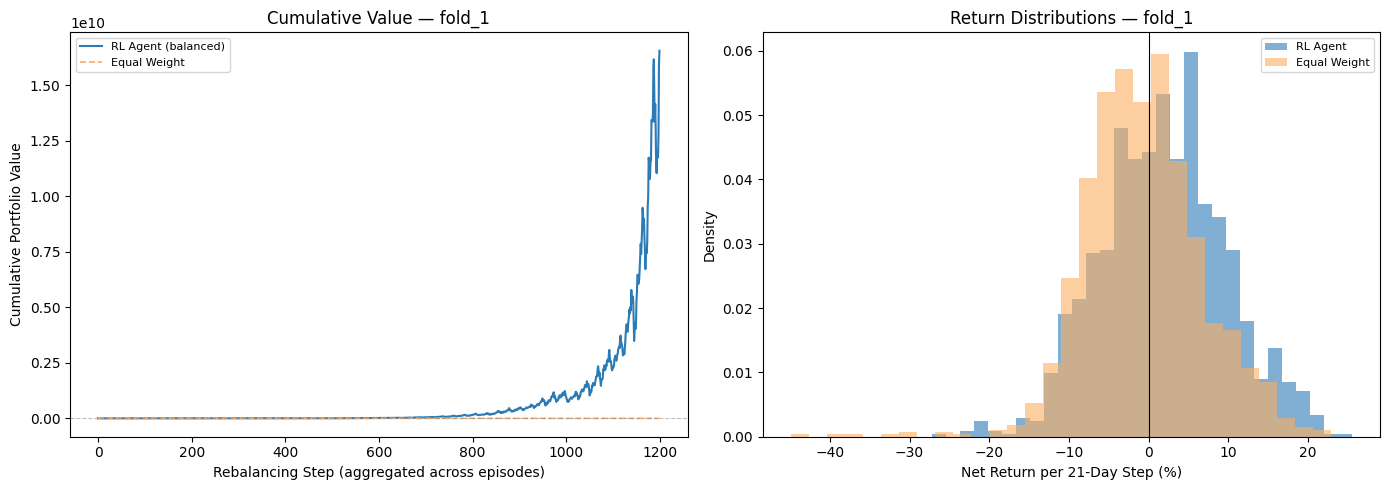

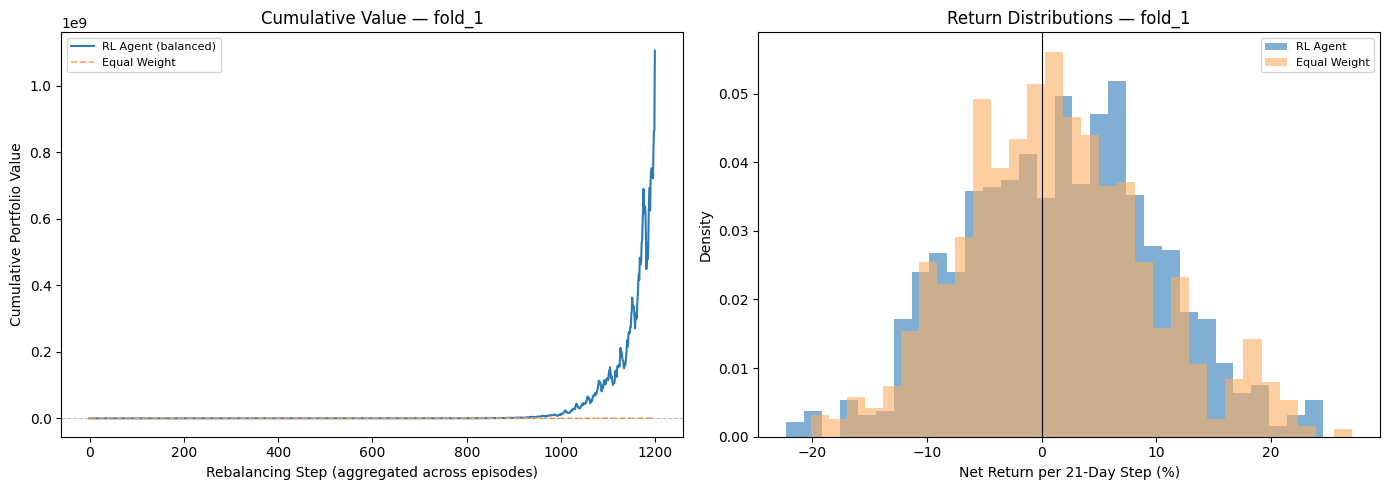


  EVALUATION — fold_2  (test -> 2022-12-31)

[VAL]
  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — val [fold_2] --
  N returns             : 1200
  Annualized return     :    41.93%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    26.58%
  Sharpe ratio          :    0.787
  Sortino ratio         :    1.651
  Max drawdown          :    19.17%
  Calmar ratio          :    2.187
  CVaR (95%, per-period):  -10.88%
  Win rate vs RFR       :    55.6%  (667/1200 periods)

-- Equal Weight — val [fold_2] --
  N returns             : 1200
  Annualized return     :    14.57%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    28.55%
  Sharpe ratio          :   -0.225
  Sortino ratio         :   -0.400
  Max drawdown          :    51.40%
  Calmar ratio          :    0.284
  CVaR (95%, per-period):  -14.55%
  Win rate vs RFR       :    45.7%  (548/1200 periods)

  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_2]
    Ann. return          

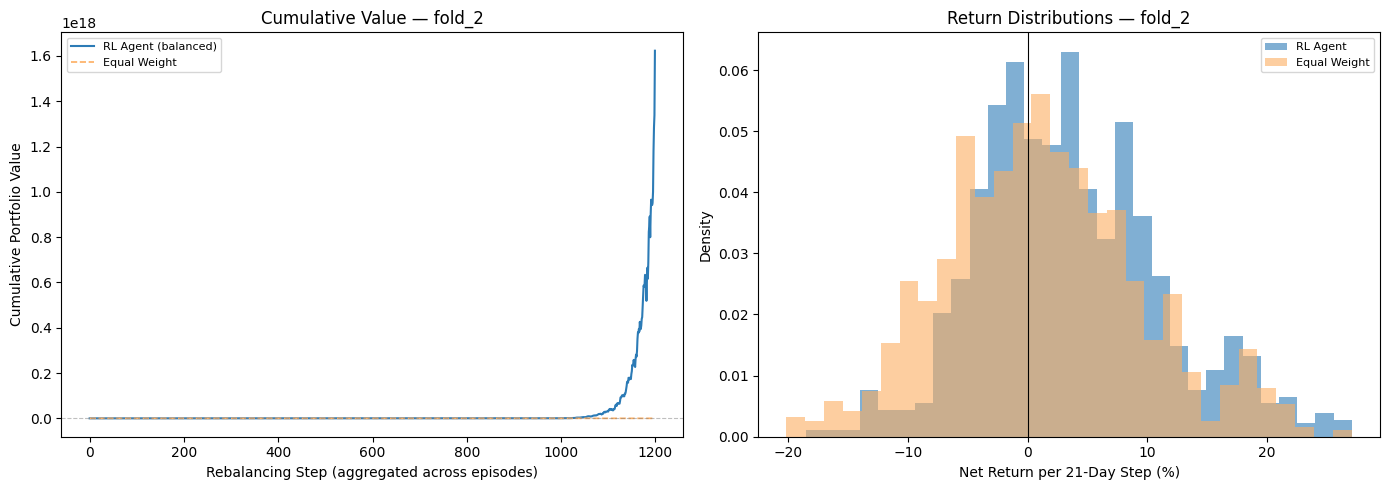

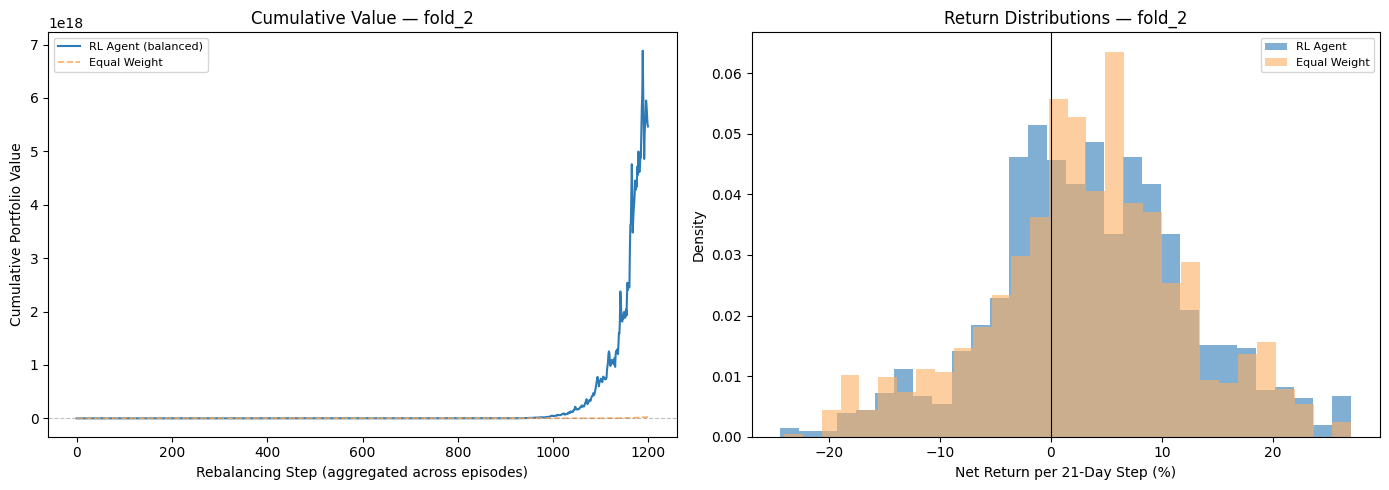


  EVALUATION — fold_3  (test -> 2023-12-31)

[VAL]
  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — val [fold_3] --
  N returns             : 1200
  Annualized return     :    63.78%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    34.37%
  Sharpe ratio          :    1.244
  Sortino ratio         :    2.023
  Max drawdown          :    39.84%
  Calmar ratio          :    1.601
  CVaR (95%, per-period):  -17.17%
  Win rate vs RFR       :    65.1%  (781/1200 periods)

-- Equal Weight — val [fold_3] --
  N returns             : 1200
  Annualized return     :    37.67%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    31.06%
  Sharpe ratio          :    0.537
  Sortino ratio         :    0.813
  Max drawdown          :    49.03%
  Calmar ratio          :    0.768
  CVaR (95%, per-period):  -17.10%
  Win rate vs RFR       :    58.9%  (706/1200 periods)

  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_3]
    Ann. return          

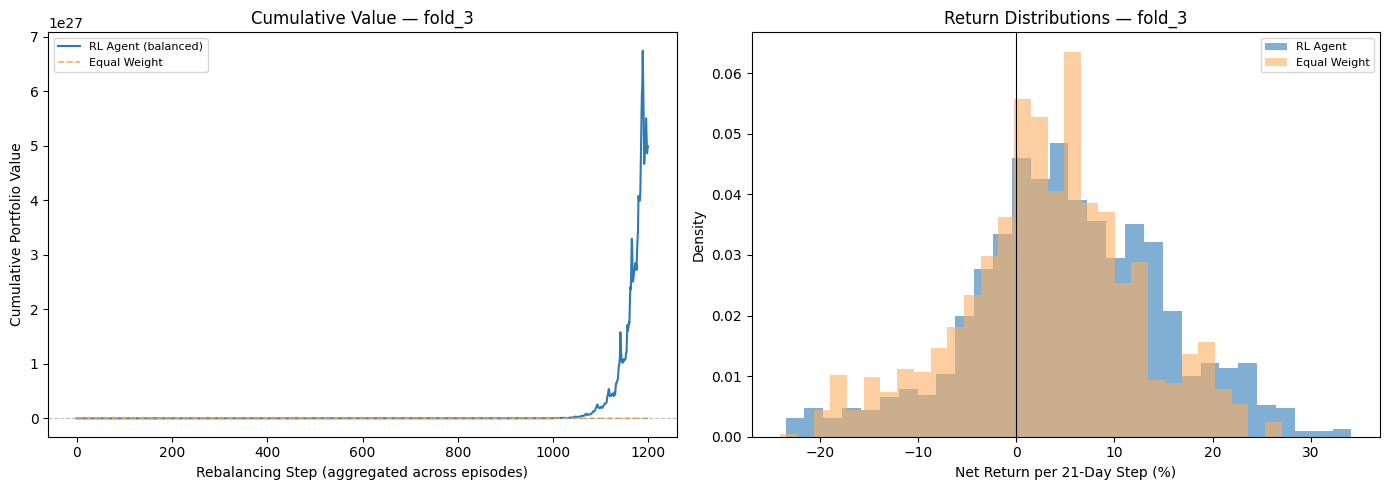

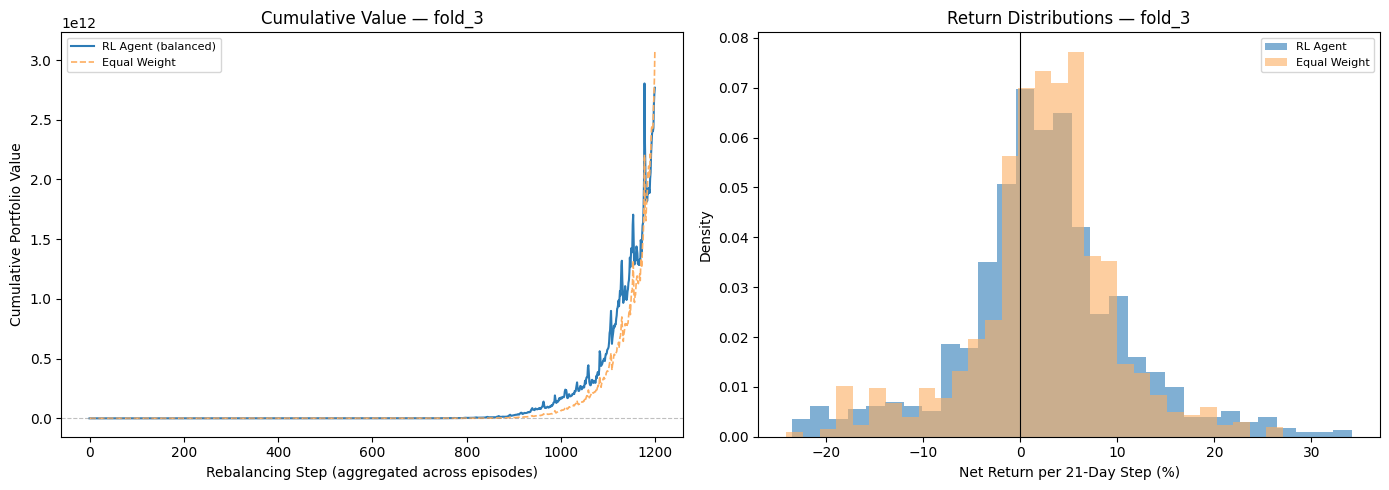


  EVALUATION — fold_4  (test -> 2025-12-31)

[VAL]
  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — val [fold_4] --
  N returns             : 1200
  Annualized return     :    63.35%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    27.66%
  Sharpe ratio          :    1.531
  Sortino ratio         :    2.951
  Max drawdown          :    22.98%
  Calmar ratio          :    2.757
  CVaR (95%, per-period):  -10.77%
  Win rate vs RFR       :    67.2%  (806/1200 periods)

-- Equal Weight — val [fold_4] --
  N returns             : 1200
  Annualized return     :    28.76%
  Risk-free (CONIA)     :    21.00%
  Annualized vol        :    25.35%
  Sharpe ratio          :    0.306
  Sortino ratio         :    0.393
  Max drawdown          :    28.03%
  Calmar ratio          :    1.026
  CVaR (95%, per-period):  -16.32%
  Win rate vs RFR       :    59.4%  (713/1200 periods)

  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_4]
    Ann. return          

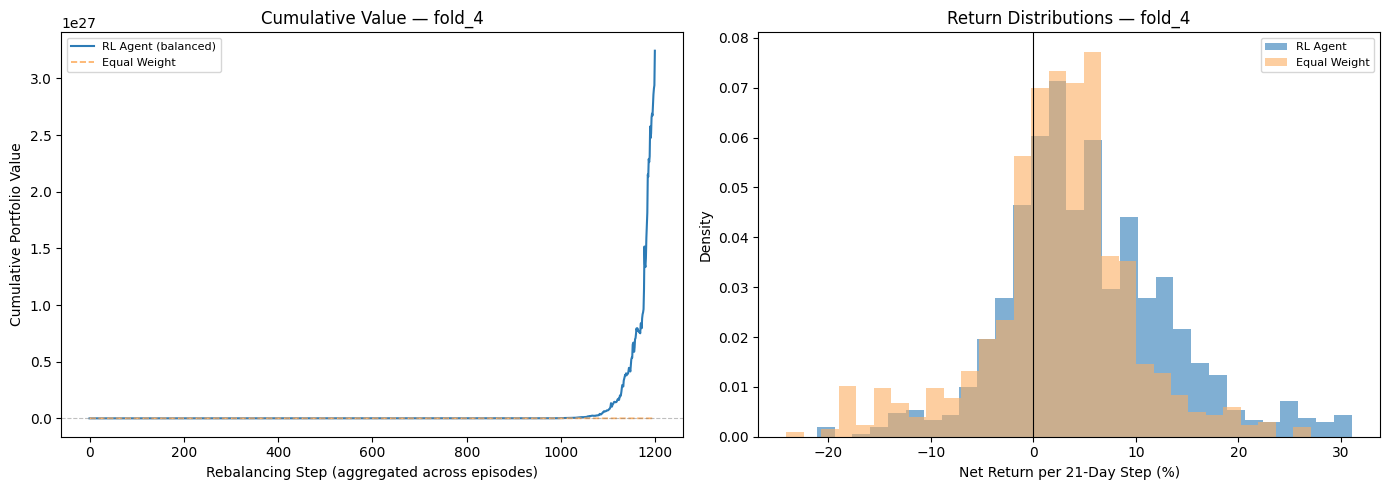

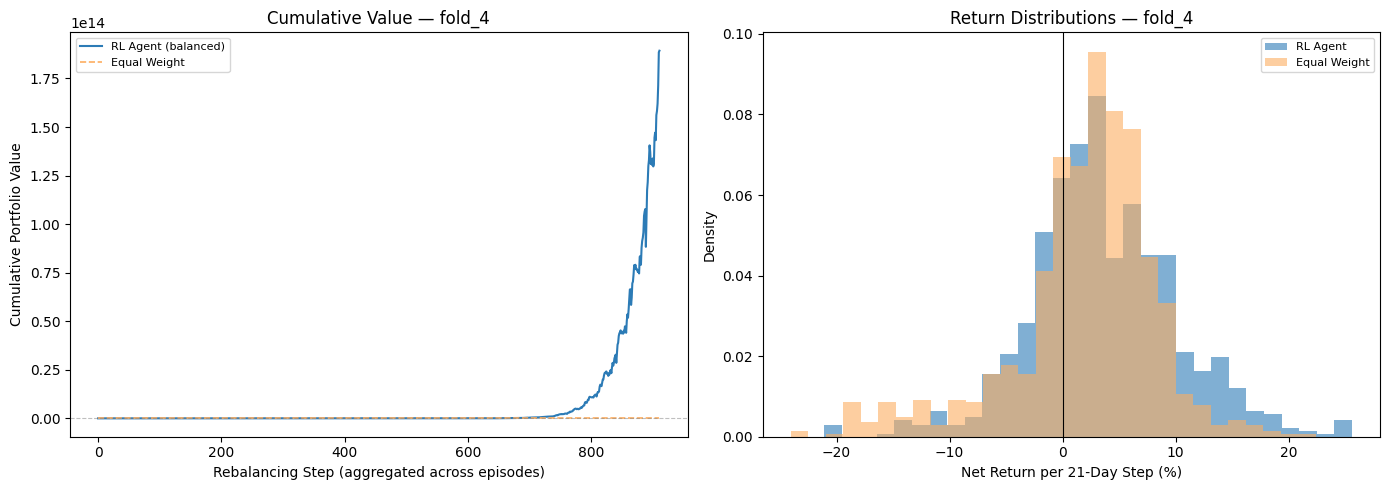


All fold evaluations complete.


In [ ]:
_template_env = PortfolioEnv(
    feature_tensor      = feature_tensor,
    returns_tensor      = returns_tensor,
    mask_tensor         = mask_tensor,
    market_signal       = market_signal,
    profile_mask_tensor = profile_mask_tensor,
    universe_indices    = universe_indices,
    split_indices       = fold_split_indices["fold_1"],
    risk_profile        = RISK_PROFILE,
    feature_names       = feature_names,
    mode                = "test",
    episode_length      = EPISODE_LENGTH,
    rebalance_days      = REBALANCE_DAYS,
    silent              = True,
)
all_fold_results = {}

for fold in WALK_FORWARD_FOLDS:
    fold_name = fold["name"]
    split     = fold_split_indices[fold_name]
    model     = fold_models[fold_name]
    plots_dir = fold_plots_dirs[fold_name]

    print(f"\n{'='*60}")
    print(f"  EVALUATION — {fold_name}  (test -> {fold['test_end']})")
    print(f"{'='*60}")

    print(f"\n[VAL]")
    rl_val_returns, rl_val_episodes = multi_episode_evaluate(
        model, _template_env, split, "val", EPISODE_LENGTH
    )
    eq_val_returns = multi_episode_equal_weight(
        _template_env, split, "val", EPISODE_LENGTH
    )
    print(f"  RL  : {len(rl_val_returns)} returns from {len(rl_val_episodes)} episodes")
    print(f"  EQW : {len(eq_val_returns)} returns")

    rl_val_metrics = compute_metrics(rl_val_returns,  f"RL Agent — val [{fold_name}]")
    eq_val_metrics = compute_metrics(eq_val_returns,   f"Equal Weight — val [{fold_name}]")
    rl_val_ci      = compute_bootstrap_cis(rl_val_returns,  f"RL val [{fold_name}]")
    eq_val_ci      = compute_bootstrap_cis(eq_val_returns,   f"EQW val [{fold_name}]")
    val_sig        = significance_test(
        rl_val_returns[:min(len(rl_val_returns), len(eq_val_returns))],
        eq_val_returns[:min(len(rl_val_returns), len(eq_val_returns))],
        label=f"val {fold_name}"
    )

    print(f"\n[TEST]")
    rl_test_returns, rl_test_episodes = multi_episode_evaluate(
        model, _template_env, split, "test", EPISODE_LENGTH
    )
    eq_test_returns = multi_episode_equal_weight(
        _template_env, split, "test", EPISODE_LENGTH
    )
    print(f"  RL  : {len(rl_test_returns)} returns from {len(rl_test_episodes)} episodes")
    print(f"  EQW : {len(eq_test_returns)} returns")

    rl_test_metrics = compute_metrics(rl_test_returns,  f"RL Agent — test [{fold_name}]")
    eq_test_metrics = compute_metrics(eq_test_returns,   f"Equal Weight — test [{fold_name}]")
    rl_test_ci      = compute_bootstrap_cis(rl_test_returns,  f"RL test [{fold_name}]")
    eq_test_ci      = compute_bootstrap_cis(eq_test_returns,   f"EQW test [{fold_name}]")
    test_sig        = significance_test(
        rl_test_returns[:min(len(rl_test_returns), len(eq_test_returns))],
        eq_test_returns[:min(len(rl_test_returns), len(eq_test_returns))],
        label=f"test {fold_name}"
    )

    print(f"\n[ACTIVE METRICS — TEST]")
    active_metrics_test = compute_active_metrics(
        rl_returns   = rl_test_returns,
        eq_returns   = eq_test_returns,
        model        = model,
        env_template = _template_env,
        split_indices = split,
        mode         = "test",
        episode_length = EPISODE_LENGTH,
        fold_name    = fold_name,
    )

    plot_fold_results(rl_val_returns,  eq_val_returns,  fold_name, "val",  plots_dir)
    plot_fold_results(rl_test_returns, eq_test_returns, fold_name, "test", plots_dir)

    fold_result = {
        "fold":              fold_name,
        "train_end":         fold["train_end"],
        "val_end":           fold["val_end"],
        "test_end":          fold["test_end"],
        "rl_val":            rl_val_metrics,
        "eq_val":            eq_val_metrics,
        "rl_val_ci":         rl_val_ci,
        "rl_test":           rl_test_metrics,
        "eq_test":           eq_test_metrics,
        "rl_test_ci":        rl_test_ci,
        "val_significance":  val_sig,
        "test_significance": test_sig,
        "active_metrics": active_metrics_test,
    }
    all_fold_results[fold_name] = fold_result

    results_dir = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / fold_name / "results"
    json.dump(fold_result, open(results_dir / "metrics.json", "w"),
              indent=2, default=str)

print(f"\nAll fold evaluations complete.")

## 13. Aggregate Results Across Folds

In [ ]:
print(f"\n{'='*65}")
print(f"  CROSS-FOLD AGGREGATE RESULTS  ({len(WALK_FORWARD_FOLDS)} folds)")
print(f"  VERSION={VERSION}  USE_FULL_UNIVERSE={USE_FULL_UNIVERSE}")
print(f"{'='*65}")

metrics_keys = ["ann_return", "ann_vol", "sharpe", "sortino", "max_dd", "calmar", "cvar_95"]

rl_test_rows = []
eq_test_rows = []

for fold_name, result in all_fold_results.items():
    rl_row = {"fold": fold_name, "test_end": result["test_end"]}
    eq_row = {"fold": fold_name, "test_end": result["test_end"]}
    for k in metrics_keys:
        rl_row[k] = result["rl_test"].get(k, np.nan)
        eq_row[k] = result["eq_test"].get(k, np.nan)
    rl_test_rows.append(rl_row)
    eq_test_rows.append(eq_row)

rl_df = pd.DataFrame(rl_test_rows).set_index("fold")
eq_df = pd.DataFrame(eq_test_rows).set_index("fold")

print(f"\n-- RL Agent — Test Metrics Per Fold --")
display_cols = ["test_end", "ann_return", "sharpe", "sortino", "max_dd", "cvar_95"]
rl_display   = rl_df[display_cols].copy()
rl_display["ann_return"] = (rl_display["ann_return"] * 100).round(2)
rl_display["max_dd"]     = (rl_display["max_dd"]     * 100).round(2)
rl_display["cvar_95"]    = (rl_display["cvar_95"]    * 100).round(2)
rl_display["sharpe"]     = rl_display["sharpe"].round(3)
rl_display["sortino"]    = rl_display["sortino"].round(3)
print(rl_display.rename(columns={"cvar_95": "cvar_95(pp%)"}).to_string())

print(f"\n-- Equal Weight — Test Metrics Per Fold --")
eq_display   = eq_df[display_cols].copy()
eq_display["ann_return"] = (eq_display["ann_return"] * 100).round(2)
eq_display["max_dd"]     = (eq_display["max_dd"]     * 100).round(2)
eq_display["cvar_95"]    = (eq_display["cvar_95"]    * 100).round(2)
eq_display["sharpe"]     = eq_display["sharpe"].round(3)
eq_display["sortino"]    = eq_display["sortino"].round(3)
print(eq_display.rename(columns={"cvar_95": "cvar_95(pp%)"}).to_string())

print(f"\n-- Cross-Fold Summary (TEST) --")
print(f"  ann_return, ann_vol, max_dd: annualized (x12 or xsqrt(12))")
print(f"  cvar_95: per-period fraction (NOT annualized)")
print(f"{'Metric':<22} {'RL Mean':>10} {'RL Std':>8} | {'EQ Mean':>10} {'EQ Std':>8}")
print("-" * 67)
for k in metrics_keys:
    rl_vals = rl_df[k].dropna().values
    eq_vals = eq_df[k].dropna().values
    scale   = 100 if k in ["ann_return", "ann_vol", "max_dd", "cvar_95"] else 1
    unit    = "%" if scale == 100 else ""
    rl_mean = np.mean(rl_vals) * scale
    rl_std  = np.std(rl_vals)  * scale
    eq_mean = np.mean(eq_vals) * scale
    eq_std  = np.std(eq_vals)  * scale
    suffix  = " (pp)" if k == "cvar_95" else ""
    print(f"{k+suffix:<22} {rl_mean:>9.2f}{unit} {rl_std:>7.2f}{unit} | "
          f"{eq_mean:>9.2f}{unit} {eq_std:>7.2f}{unit}")

print(f"\n-- Fold-Level Significance Summary --")
sig_rows = []
for fold_name, result in all_fold_results.items():
    sig = result["test_significance"]
    sig_rows.append({
        "fold":      fold_name,
        "direction": sig.get("direction", "?"),
        "t_pval":    sig.get("t_pval", np.nan),
        "w_pval":    sig.get("w_pval", np.nan),
        "sig_t":     "OK" if sig.get("t_pval", 1) < 0.05 else "x",
        "sig_w":     "OK" if sig.get("w_pval", 1) < 0.05 else "x",
    })
sig_df = pd.DataFrame(sig_rows).set_index("fold")
print(sig_df[["direction", "t_pval", "sig_t", "w_pval", "sig_w"]].round(4).to_string())

n_outperforms   = ((sig_df["t_pval"] < 0.05) & (sig_df["direction"] == "outperforms")).sum()
n_underperforms = ((sig_df["t_pval"] < 0.05) & (sig_df["direction"] == "underperforms")).sum()
print(f"\nRL significantly outperforms EQW  : {n_outperforms}/{len(WALK_FORWARD_FOLDS)} folds")
print(f"RL significantly underperforms EQW: {n_underperforms}/{len(WALK_FORWARD_FOLDS)} folds")

print(f"\n-- Active Metrics Summary (TEST) --")
print(f"{'Metric':<25} {'Mean':>10} {'Std':>8}")
print("-" * 46)

active_keys = ["information_ratio", "win_rate_vs_eq", "avg_turnover", "avg_active_stocks"]
active_labels = {
    "information_ratio":  ("Information Ratio",  1,    ""),
    "win_rate_vs_eq":     ("Win Rate vs EQW",    100,  "%"),
    "avg_turnover":       ("Avg Turnover/step",  100,  "%"),
    "avg_active_stocks":  ("Avg Active Stocks",  1,    ""),
}

for key in active_keys:
    vals = [
        all_fold_results[f]["active_metrics"][key]
        for f in all_fold_results.keys()
        if "active_metrics" in all_fold_results[f]
    ]
    if not vals:
        continue
    label, scale, unit = active_labels[key]
    mean_val = np.mean(vals) * scale
    std_val  = np.std(vals)  * scale
    print(f"{label:<25} {mean_val:>9.2f}{unit} {std_val:>7.2f}{unit}")


  CROSS-FOLD AGGREGATE RESULTS  (4 folds)
  VERSION=v7_a2  USE_FULL_UNIVERSE=False

-- RL Agent — Test Metrics Per Fold --
          test_end  ann_return  sharpe  sortino  max_dd  cvar_95(pp%)
fold                                                                 
fold_1  2021-12-31       20.82  -0.006   -0.010   39.72        -14.96
fold_2  2022-12-31       43.14   0.717    1.217   38.77        -15.79
fold_3  2023-12-31       28.65   0.256    0.372   40.20        -18.10
fold_4  2025-12-31       43.26   0.976    1.583   22.98        -10.72

-- Equal Weight — Test Metrics Per Fold --
          test_end  ann_return  sharpe  sortino  max_dd  cvar_95(pp%)
fold                                                                 
fold_1  2021-12-31       14.57  -0.225   -0.400   51.40        -14.55
fold_2  2022-12-31       37.67   0.537    0.813   49.03        -17.10
fold_3  2023-12-31       28.76   0.306    0.393   28.03        -16.32
fold_4  2025-12-31       23.32   0.104    0.116   28.03       

## 14. Aggregate Plot + Signal/Cash Diagnostic

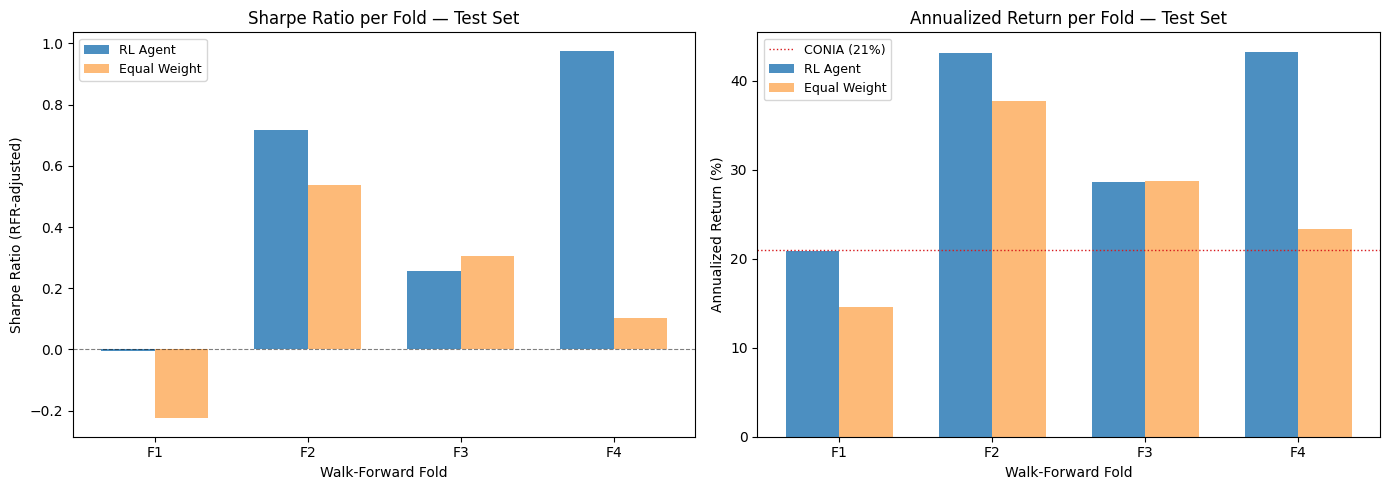


Aggregate results saved to C:\Users\mirae\Desktop\Personalization_Engine\outputs\balanced\v7_a2\aggregate

-- Final Summary --
VERSION         : v7_a2  (USE_FULL_UNIVERSE=False)
RL  mean Sharpe : +0.486 +/- 0.384
EQW mean Sharpe : +0.180 +/- 0.280
Sharpe margin   : +0.305  (v7 reference: +0.311)
RL  mean return : +34.0%
EQW mean return : +26.1%
RL significantly outperforms EQW   : 3/4 folds
RL significantly underperforms EQW : 0/4 folds


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds_list = list(all_fold_results.keys())
rl_sharpes = [all_fold_results[f]["rl_test"]["sharpe"]     for f in folds_list]
eq_sharpes = [all_fold_results[f]["eq_test"]["sharpe"]     for f in folds_list]
rl_returns = [all_fold_results[f]["rl_test"]["ann_return"] * 100 for f in folds_list]
eq_returns = [all_fold_results[f]["eq_test"]["ann_return"] * 100 for f in folds_list]

x = np.arange(len(folds_list))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, rl_sharpes, width=w, color=PALETTE["primary"],  alpha=0.85, label="RL Agent")
ax.bar(x + w/2, eq_sharpes, width=w, color=PALETTE["tertiary"], alpha=0.85, label="Equal Weight")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Walk-Forward Fold")
ax.set_ylabel("Sharpe Ratio (RFR-adjusted)")
ax.set_title("Sharpe Ratio per Fold — Test Set")
ax.set_xticks(x)
ax.set_xticklabels([f.replace("fold_", "F") for f in folds_list])
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.bar(x - w/2, rl_returns, width=w, color=PALETTE["primary"],  alpha=0.85, label="RL Agent")
ax2.bar(x + w/2, eq_returns, width=w, color=PALETTE["tertiary"], alpha=0.85, label="Equal Weight")
ax2.axhline(ANNUAL_RISK_FREE_RATE * 100, color=PALETTE["alert"],
            linewidth=1.0, linestyle=":", label=f"CONIA ({ANNUAL_RISK_FREE_RATE*100:.0f}%)")
ax2.set_xlabel("Walk-Forward Fold")
ax2.set_ylabel("Annualized Return (%)")
ax2.set_title("Annualized Return per Fold — Test Set")
ax2.set_xticks(x)
ax2.set_xticklabels([f.replace("fold_", "F") for f in folds_list])
ax2.legend(fontsize=9)

plt.tight_layout()
agg_plots_dir = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / "aggregate"
agg_plots_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(agg_plots_dir / "fold_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

agg_summary = {
    "n_folds":           len(WALK_FORWARD_FOLDS),
    "risk_profile":      RISK_PROFILE,
    "version":           VERSION,
    "use_full_universe": USE_FULL_UNIVERSE,
    "market_signal":     meta.get("market_signal", "egx30_ma_ratio + conia_delta"),
    "universe_mode":     "full 31-stock (classifier removed)" if USE_FULL_UNIVERSE
                         else "profile_mask_tensor (v7 behaviour)",
    "folds":             [f["name"] for f in WALK_FORWARD_FOLDS],
    "rl_mean_sharpe":    float(np.mean(rl_sharpes)),
    "rl_std_sharpe":     float(np.std(rl_sharpes)),
    "eq_mean_sharpe":    float(np.mean(eq_sharpes)),
    "eq_std_sharpe":     float(np.std(eq_sharpes)),
    "sharpe_margin":     float(np.mean(rl_sharpes) - np.mean(eq_sharpes)),
    "rl_mean_return":    float(np.mean(rl_returns)),
    "eq_mean_return":    float(np.mean(eq_returns)),
    "n_outperforms":     int(n_outperforms),
    "n_underperforms":   int(n_underperforms),
}
json.dump(agg_summary,
          open(agg_plots_dir / "aggregate_summary.json", "w"), indent=2)

print(f"\nAggregate results saved to {agg_plots_dir.resolve()}")
print(f"\n-- Final Summary --")
print(f"VERSION         : {VERSION}  (USE_FULL_UNIVERSE={USE_FULL_UNIVERSE})")
print(f"RL  mean Sharpe : {agg_summary['rl_mean_sharpe']:+.3f} +/- {agg_summary['rl_std_sharpe']:.3f}")
print(f"EQW mean Sharpe : {agg_summary['eq_mean_sharpe']:+.3f} +/- {agg_summary['eq_std_sharpe']:.3f}")
print(f"Sharpe margin   : {agg_summary['sharpe_margin']:+.3f}  (v7 reference: +0.311)")
print(f"RL  mean return : {agg_summary['rl_mean_return']:+.1f}%")
print(f"EQW mean return : {agg_summary['eq_mean_return']:+.1f}%")
print(f"RL significantly outperforms EQW   : {n_outperforms}/{len(WALK_FORWARD_FOLDS)} folds")
print(f"RL significantly underperforms EQW : {n_underperforms}/{len(WALK_FORWARD_FOLDS)} folds")

In [ ]:
# Signal/cash correlation diagnostic
for fold_name, result in all_fold_results.items():
    split = fold_split_indices[fold_name]
    model = fold_models[fold_name]

    eval_env = PortfolioEnv(
        feature_tensor      = feature_tensor,
        returns_tensor      = returns_tensor,
        mask_tensor         = mask_tensor,
        market_signal       = market_signal,
        profile_mask_tensor = profile_mask_tensor,
        universe_indices    = universe_indices,
        split_indices       = split,
        risk_profile        = RISK_PROFILE,
        feature_names       = feature_names,
        mode                = "test",
        episode_length      = EPISODE_LENGTH,
        rebalance_days      = REBALANCE_DAYS,
        silent              = True,
    )

    signals, cash_weights = [], []
    obs, _ = eval_env.reset()
    for _ in range(EPISODE_LENGTH):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, _, truncated, info = eval_env.step(action)
        day_idx = eval_env.start_idx + (eval_env.current_step - 1) * REBALANCE_DAYS
        signals.append(float(market_signal[day_idx, 0]))
        cash_weights.append(info["current_weights"][-1])
        if truncated:
            break

    corr = np.corrcoef(signals, cash_weights)[0, 1]
    print(f"{fold_name}: signal<->cash correlation = {corr:+.3f}  "
          f"({'using signal' if corr < -0.1 else 'not using signal'})")

fold_1: signal<->cash correlation = -0.315  (using signal)
fold_2: signal<->cash correlation = -0.395  (using signal)
fold_3: signal<->cash correlation = -0.452  (using signal)
fold_4: signal<->cash correlation = -0.154  (using signal)
